# Import Libraries

In [2]:
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [4]:
womens_world_cup_stats = pd.read_csv(
    '/Users/gui/womens_world_cup_2023_statsbomb_final.csv'
)

In [6]:
womens_world_cup_stats

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,3904629,2023-08-16,England Women's,Australia Women's,Semi-finals,3,1,W,3,49.971523,...,1.0,1,19,12.0,7,16,30,51,3,0
124,3906389,2023-08-19,Australia Women's,Sweden Women's,Third-place,0,2,L,0,52.821967,...,0.0,0,18,11.0,17,27,9,66,3,0
125,3906389,2023-08-19,Sweden Women's,Australia Women's,Third-place,2,0,W,3,47.178033,...,1.0,0,26,16.0,12,31,29,65,4,1
126,3906390,2023-08-20,England Women's,Spain Women's,Final,0,1,L,0,44.284665,...,0.0,0,25,13.0,7,24,18,54,4,0


# Filter the Group Stage

In [9]:
group_stage = womens_world_cup_stats[
    womens_world_cup_stats['stage'] == 'Group'
]

In [11]:
group_stage

,match_id,match_date,team,opponent,stage,goals_for,goals_against,result,points,possession_pct,...,goals_after_turnover,set_piece_goals,tackles,tackles_won,interceptions,blocks,clearances,recoveries,saves,clean_sheet
0,3893787,2023-07-20,New Zealand Women's,Norway Women's,Group,1,0,W,3,57.781529,...,0.0,1,27,13.0,8,28,24,72,2,1
1,3893787,2023-07-20,Norway Women's,New Zealand Women's,Group,0,1,L,0,42.218471,...,0.0,0,23,11.0,12,31,42,60,1,0
2,3893788,2023-07-20,Australia Women's,Republic of Ireland Women's,Group,1,0,W,3,58.013378,...,0.0,0,19,11.0,5,23,33,72,1,1
3,3893788,2023-07-20,Republic of Ireland Women's,Australia Women's,Group,0,1,L,0,41.986622,...,0.0,0,26,15.0,8,23,17,57,1,0
4,3893789,2023-07-21,Philippines Women's,Switzerland Women's,Group,0,2,L,0,30.212373,...,0.0,0,14,5.0,13,20,33,53,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,3893832,2023-08-02,Jamaica Women's,Brazil Women's,Group,0,0,D,1,29.464669,...,0.0,0,22,12.0,13,30,46,67,8,1
92,3893833,2023-08-03,Germany Women's,Korea Republic Women's,Group,1,1,D,1,60.364924,...,0.0,0,16,10.0,14,14,32,64,1,0
93,3893833,2023-08-03,Korea Republic Women's,Germany Women's,Group,1,1,D,1,39.635076,...,0.0,0,25,12.0,10,28,26,64,2,0
94,3893834,2023-08-03,Colombia Women's,Morocco Women's,Group,0,1,L,0,58.744898,...,0.0,0,28,13.0,22,28,18,81,5,0


In [13]:
teams = womens_world_cup_stats["team"].unique()

list(teams)

["New Zealand Women's",
 "Norway Women's",
 "Australia Women's",
 "Republic of Ireland Women's",
 "Philippines Women's",
 "Switzerland Women's",
 "Canada Women's",
 "Nigeria Women's",
 "Costa Rica Women's",
 "Spain Women's",
 "United States Women's",
 "Vietnam Women's",
 "Japan Women's",
 'Zambia W',
 "England Women's",
 "Haiti Women's",
 "China PR Women's",
 "Denmark Women's",
 "South Africa Women's",
 "Sweden Women's",
 "Netherlands Women's",
 "Portugal Women's",
 "France Women's",
 "Jamaica Women's",
 "Germany Women's",
 "Morocco Women's",
 "Argentina Women's",
 "Italy Women's",
 "Brazil Women's",
 "Panama Women's",
 "Colombia Women's",
 "Korea Republic Women's"]

# Analysis Sweden's Group Stage games

In [17]:
team = "Sweden Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
18,3893796,South Africa Women's,Sweden Women's,Group
19,3893796,Sweden Women's,South Africa Women's,Group
54,3893814,Italy Women's,Sweden Women's,Group
55,3893814,Sweden Women's,Italy Women's,Group
86,3893830,Argentina Women's,Sweden Women's,Group
87,3893830,Sweden Women's,Argentina Women's,Group


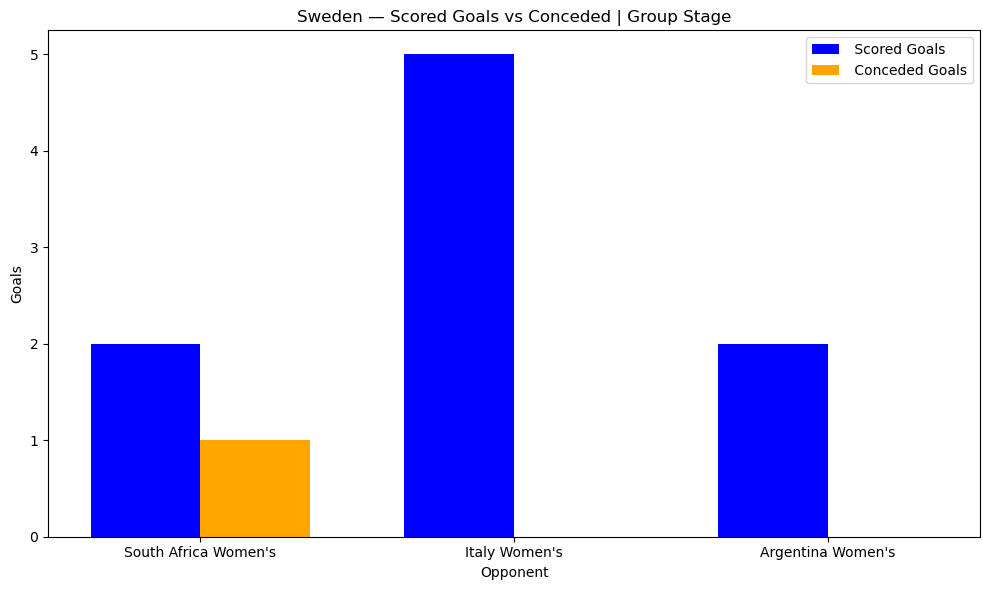

In [19]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Sweden Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Sweden — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Sweden won the three matches played in the group stage, with a total of 9 goals scored and 1 conceded goal.

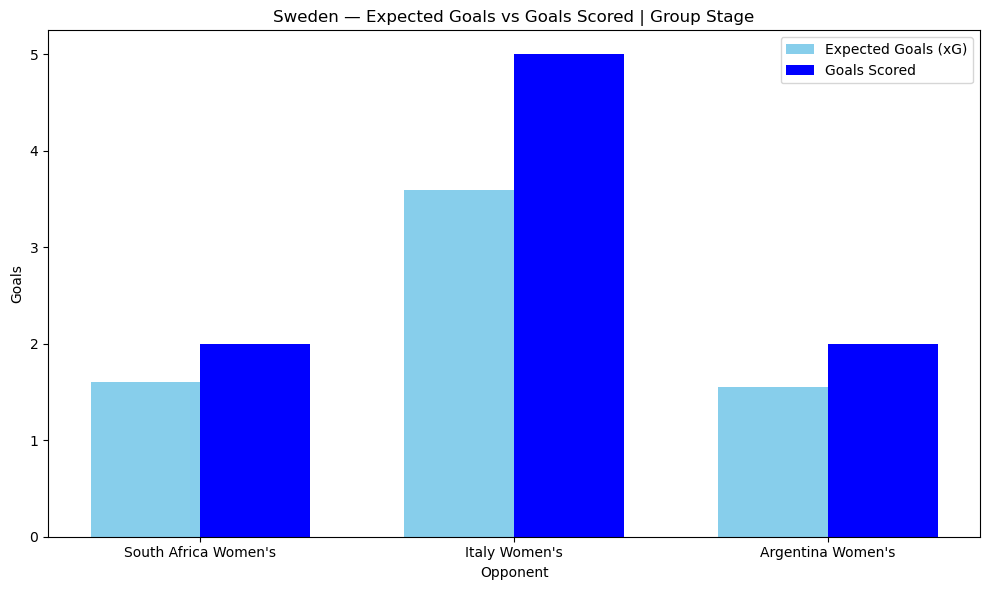

In [22]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Sweden Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Sweden — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Sweden was always above the expectations xG showing strong performance.

# Analysis SWE-RSA

In [32]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "South Africa": [
        match.loc[
            match["team"] == "South Africa Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "South Africa"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "South Africa"]
].round(1)


# Display table

comparison

,Metric,Sweden,South Africa
0,Goals,2.0,1.0
1,xG,1.6,1.0
2,Goals Minus xG,0.4,-0.0
3,Shots,16.0,10.0
4,Shots on Target,6.0,4.0
5,Saves,3.0,4.0
6,Possession %,68.0,32.0
7,Pass Accuracy %,77.8,57.9
8,Progressive Passes,152.0,78.0
9,Progressive Carries,16.0,14.0


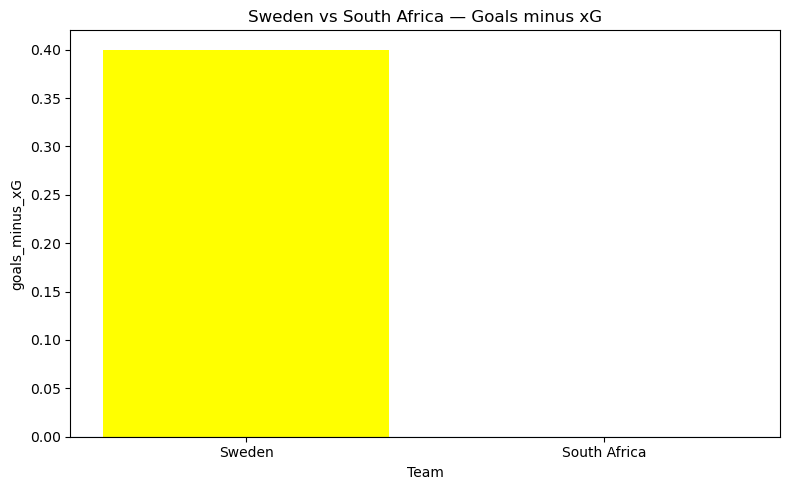

In [36]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


teams = ["Sweden", "South Africa"]

goals_minus_xG = [
    match.loc[match["team"] == "Sweden Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "South Africa Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["yellow", "forestgreen"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Sweden vs South Africa — Goals minus xG")

plt.tight_layout()
plt.show()

As noted earlier, Sweden exceeded its xG by scoring more goals than expected. South Africa, on the other hand, matched its xG (1 goal).

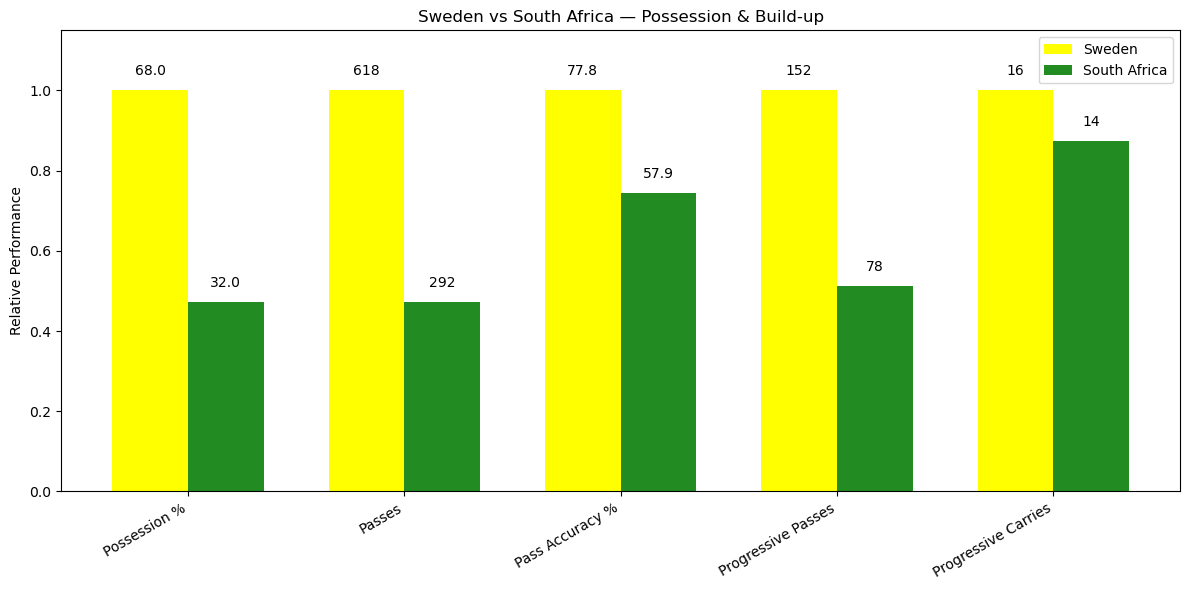

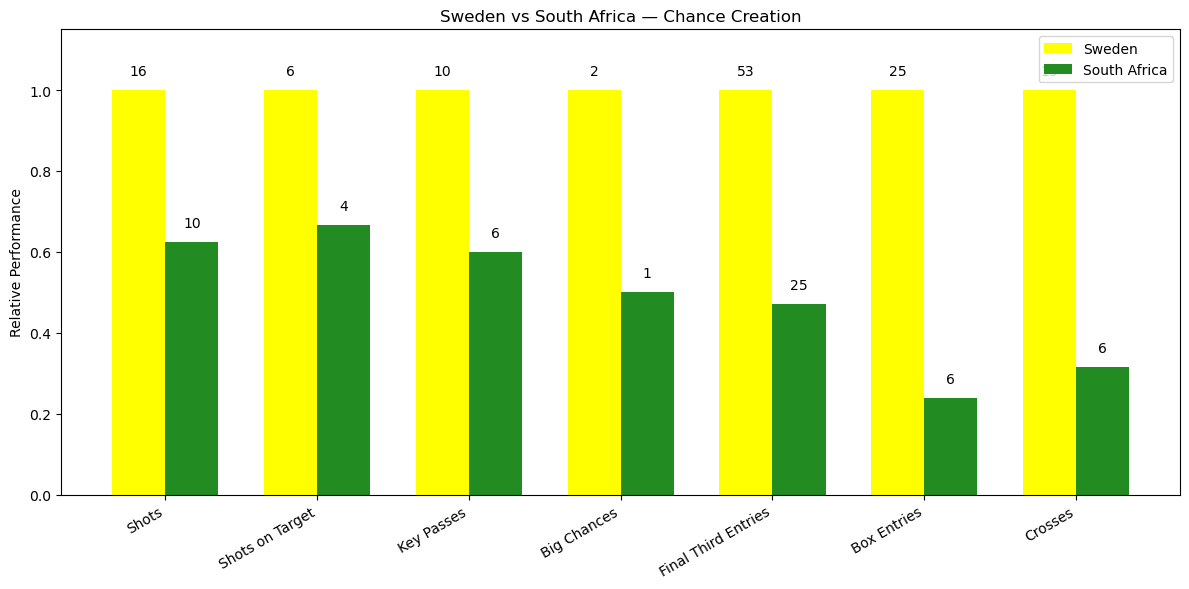

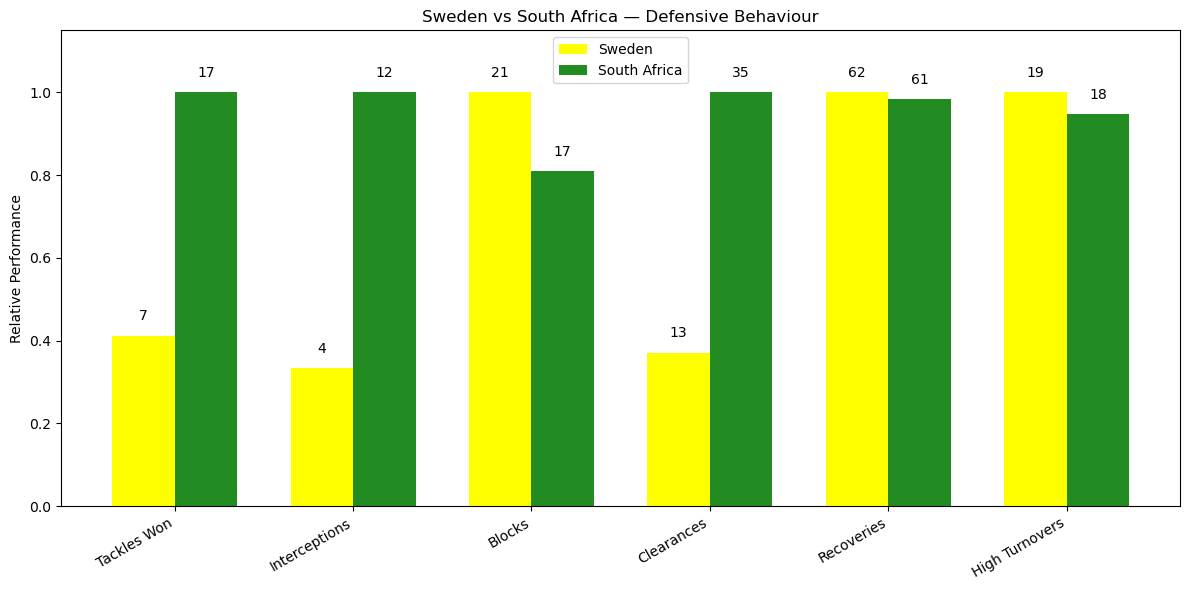

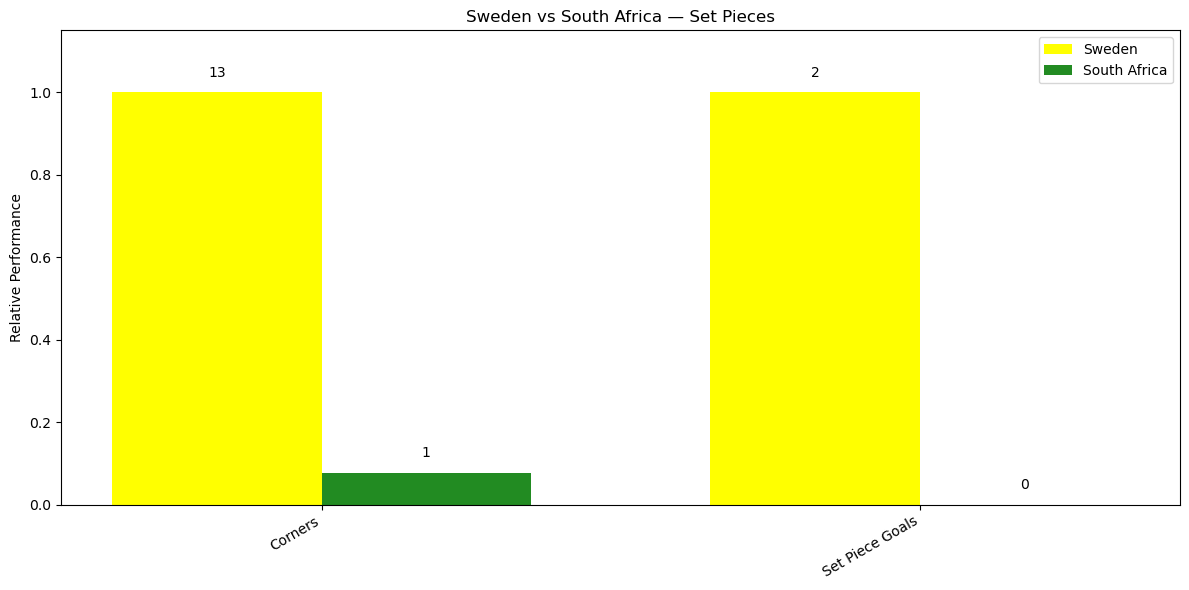

In [83]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Sweden": "Sweden Women's",
    "South Africa": "South Africa Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    swe_values = np.array([
        match.loc[
            match["team"] == team_names["Sweden"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    rsa_values = np.array([
        match.loc[
            match["team"] == team_names["South Africa"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(swe_values, rsa_values)

    # Normalize
    swe_normalized = np.divide(
        swe_values,
        max_values,
        out=np.zeros_like(swe_values),
        where=max_values != 0
    )

    rsa_normalized = np.divide(
        rsa_values,
        max_values,
        out=np.zeros_like(rsa_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_swe = plt.bar(
        x - width / 2,
        swe_normalized,
        width,
        label="Sweden",
        color="yellow"
    )

    bars_rsa = plt.bar(
        x + width / 2,
        rsa_normalized,
        width,
        label="South Africa",
        color="forestgreen"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_swe, swe_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_rsa, rsa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Sweden vs South Africa — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion of SWE-RSA

In the charts shown above, Sweden’s clear dominance is evident, particularly in the *Possession & Build-up* and *Chance Creation* charts. <br>
South Africa’s high defensive metrics are a response to Sweden’s attack.

# Analysis SWE-ITA

In [46]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Italy": [
        match.loc[
            match["team"] == "Italy Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "Italy"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "I"]
].round(1)


# Display table

comparison

,Metric,Sweden,Italy
0,Goals,5.0,0.0
1,xG,3.6,0.7
2,Goals Minus xG,1.4,-0.7
3,Shots,21.0,12.0
4,Shots on Target,7.0,2.0
5,Saves,2.0,2.0
6,Possession %,47.5,52.5
7,Pass Accuracy %,74.7,78.9
8,Progressive Passes,108.0,132.0
9,Progressive Carries,19.0,20.0


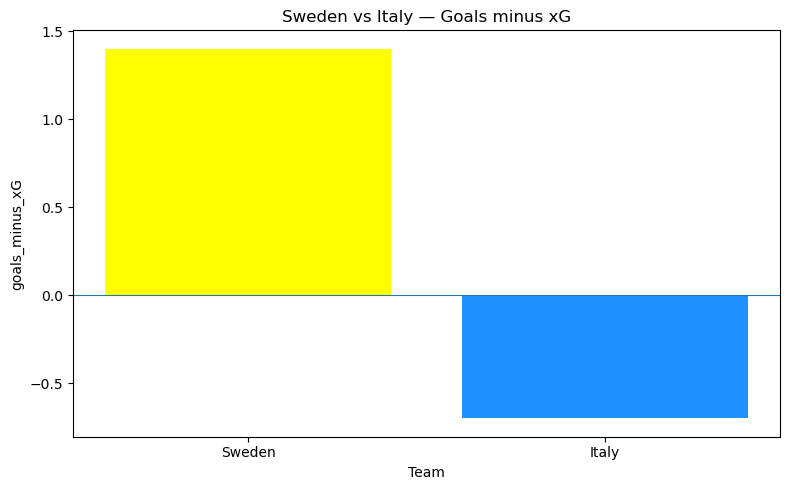

In [91]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


teams = ["Sweden", "Italy"]

goals_minus_xG = [
    match.loc[match["team"] == "Sweden Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Italy Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["yellow", "dodgerblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Sweden vs Italy — Goals minus xG")

plt.tight_layout()
plt.show()

1.4 for Sweden—that is, they scored 1.4 goals more than would be expected based on the quality of their chances. Italy finished at −0.7.

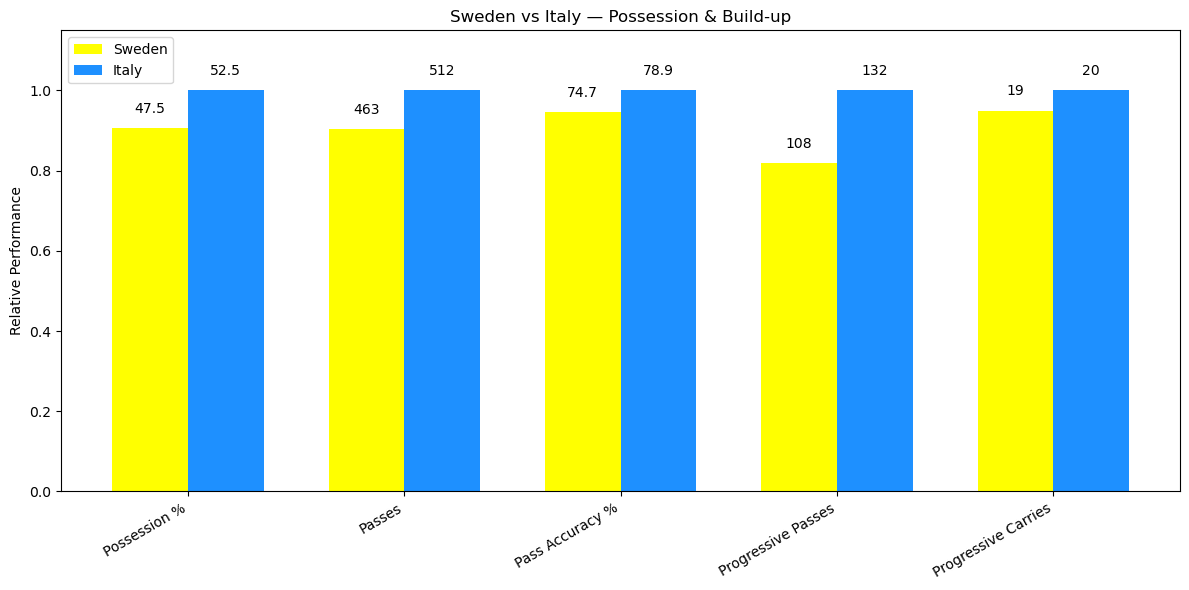

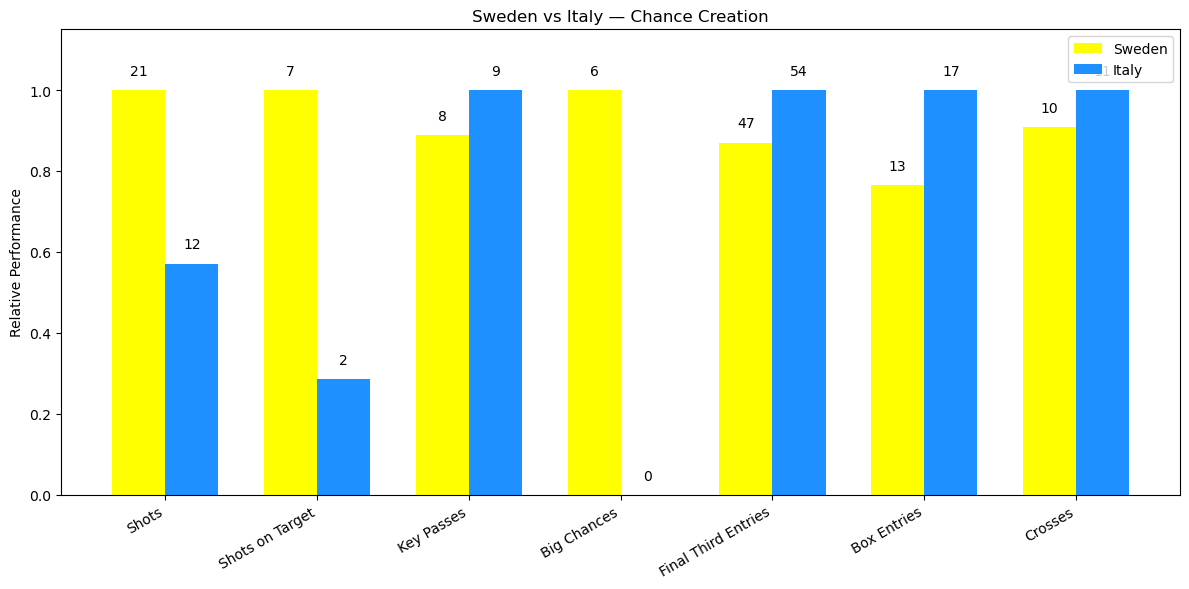

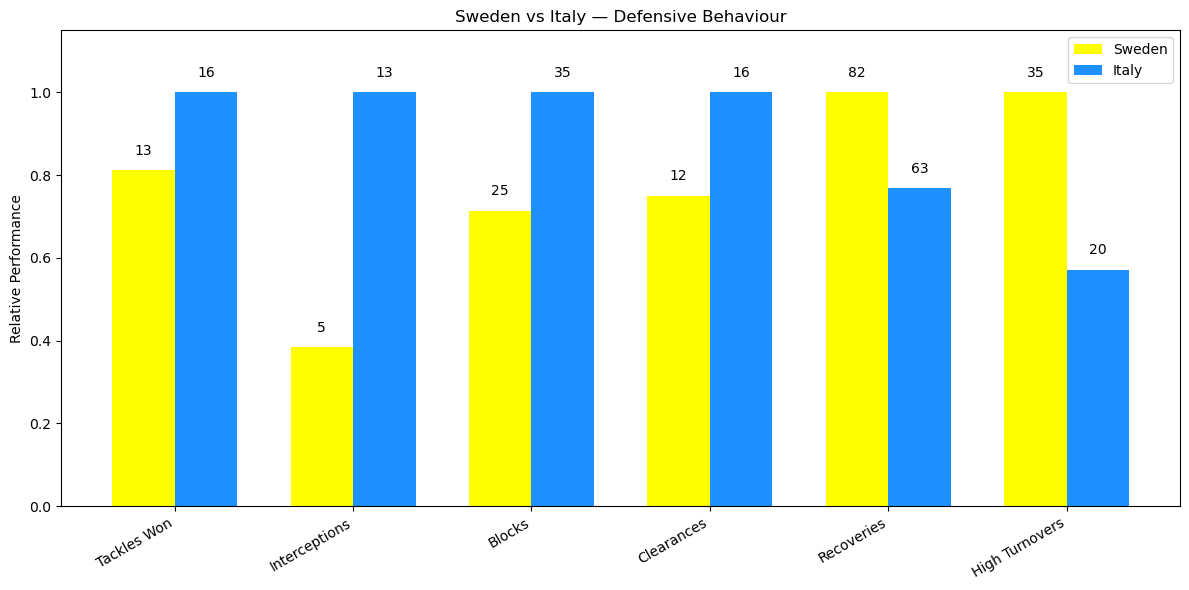

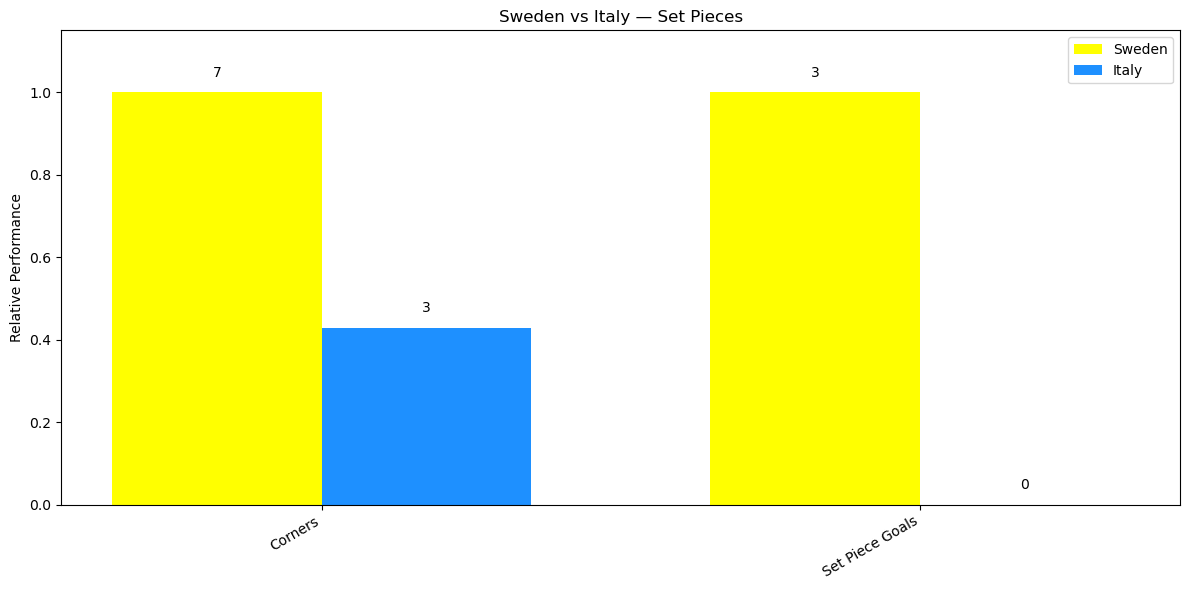

In [55]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Sweden": "Sweden Women's",
    "Italy": "Italy Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    swe_values = np.array([
        match.loc[
            match["team"] == team_names["Sweden"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    ita_values = np.array([
        match.loc[
            match["team"] == team_names["Italy"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(swe_values, ita_values)

    # Normalize
    swe_normalized = np.divide(
        swe_values,
        max_values,
        out=np.zeros_like(swe_values),
        where=max_values != 0
    )

    ita_normalized = np.divide(
        ita_values,
        max_values,
        out=np.zeros_like(ita_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_swe = plt.bar(
        x - width / 2,
        swe_normalized,
        width,
        label="Sweden",
        color="yellow"
    )

    bars_ita = plt.bar(
        x + width / 2,
        ita_normalized,
        width,
        label="Italy",
        color="dodgerblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_swe, swe_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_ita, ita_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Sweden vs Italy — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion SWE-ITA

Sweden was far more productive than Italy, even though Italy had more possession and more attacking plays. Sweden created more shots (21 to 12), more shots on goal (7 to 2), and generated a significantly higher xG (3.6 to 0.7). Their offensive efficiency was also reflected in the final score, with Sweden converting their chances into five goals. Italy had more possession and advanced further up the field, but struggled to turn that into dangerous opportunities.

# Analysis SWE-ARG

In [61]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Sweden": [
        match.loc[
            match["team"] == "Sweden Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Argentina": [
        match.loc[
            match["team"] == "Argentina Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "Argentina"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Sweden", "Argentina"]
].round(1)


# Display table

comparison

,Metric,Sweden,Argentina
0,Goals,2.0,0.0
1,xG,1.6,0.3
2,Goals Minus xG,0.4,-0.3
3,Shots,7.0,6.0
4,Shots on Target,3.0,2.0
5,Saves,2.0,1.0
6,Possession %,55.9,44.1
7,Pass Accuracy %,77.2,70.5
8,Progressive Passes,108.0,73.0
9,Progressive Carries,15.0,8.0


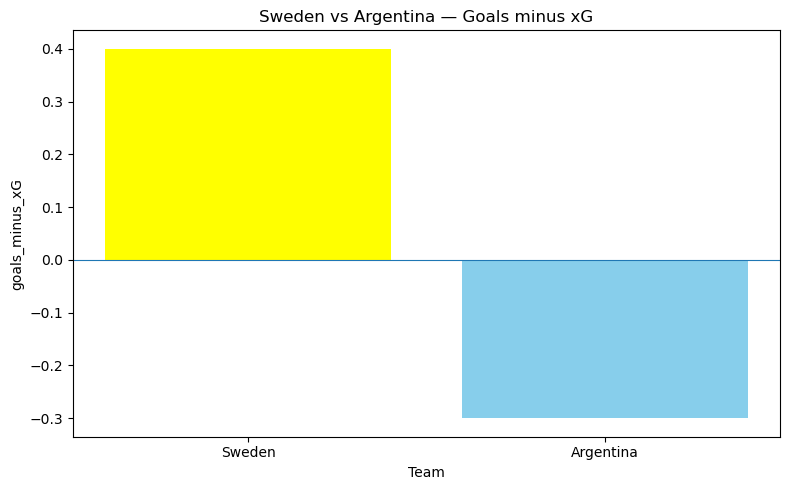

In [63]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()

teams = ["Sweden", "Argentina"]

goals_minus_xG = [
    match.loc[match["team"] == "Sweden Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Argentina Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["yellow", "skyblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Sweden vs Argentina — Goals minus xG")

plt.tight_layout()
plt.show()

Sweden, like the other matches disputed, was above the xG. In the other hand, Argentina, was bellow expectations not scorring a goal.

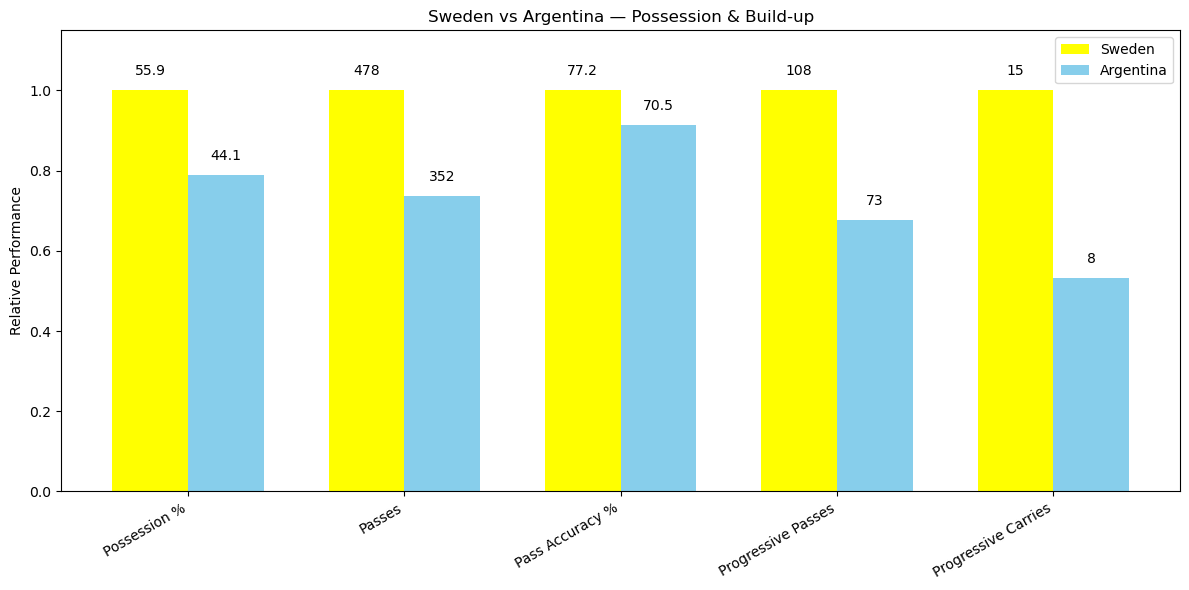

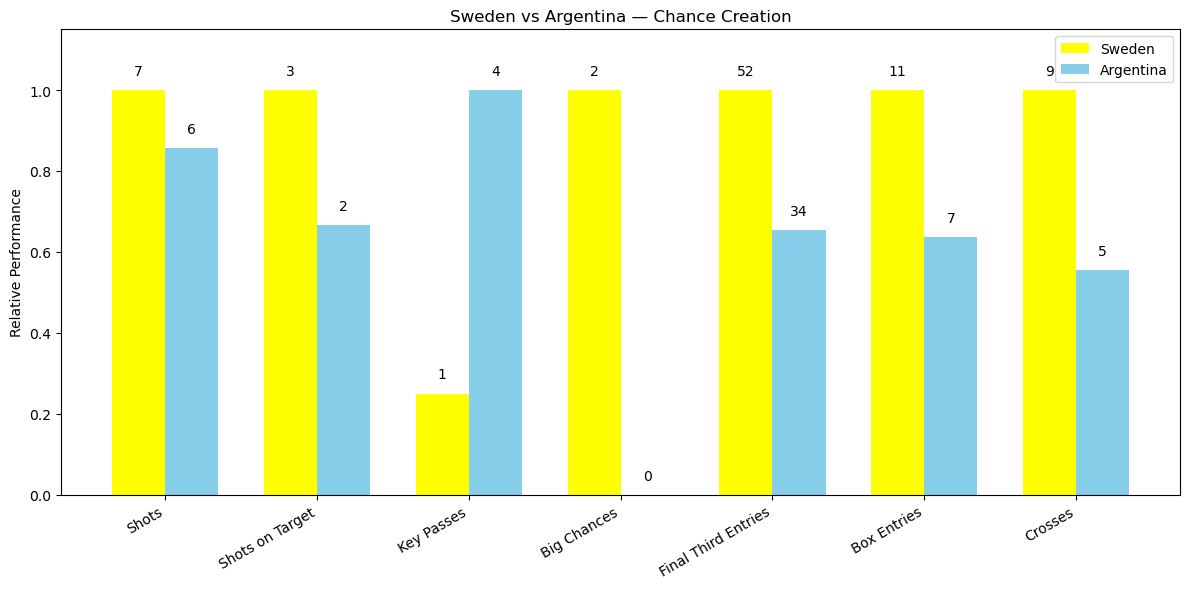

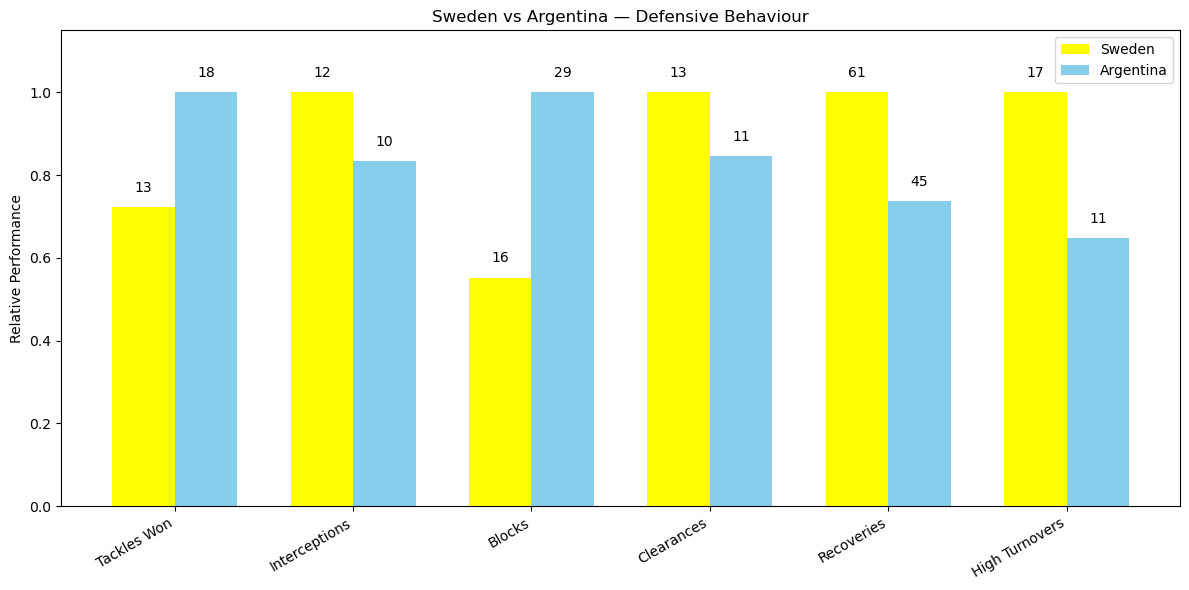

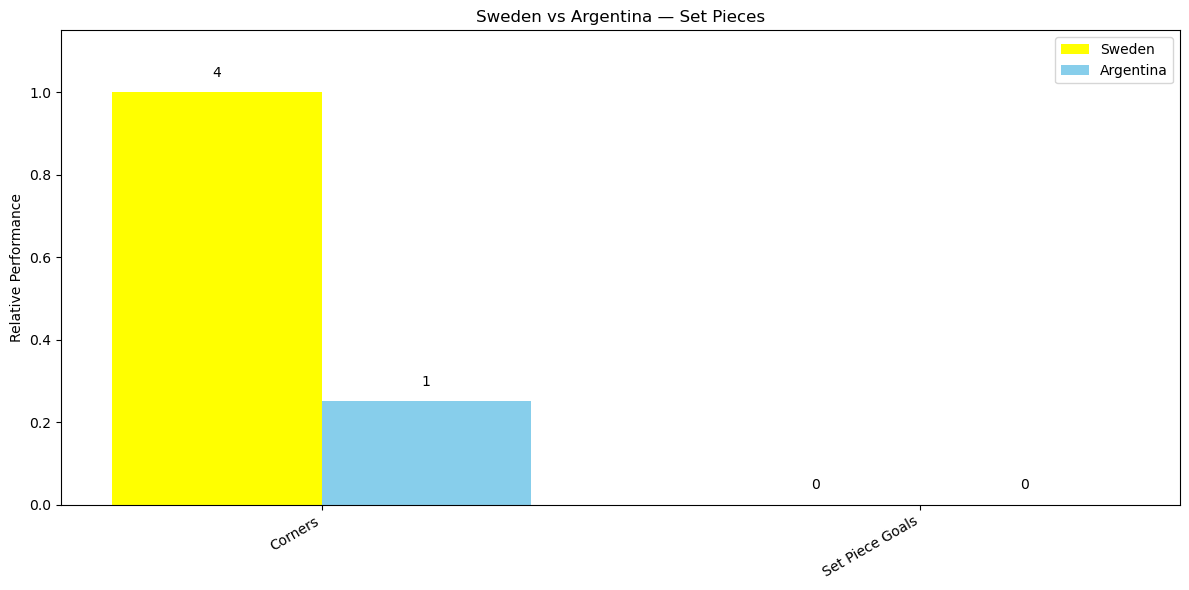

In [70]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Sweden Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "Sweden Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Sweden": "Sweden Women's",
    "Argentina": "Argentina Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    swe_values = np.array([
        match.loc[
            match["team"] == team_names["Sweden"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    arg_values = np.array([
        match.loc[
            match["team"] == team_names["Argentina"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(swe_values, arg_values)

    # Normalize
    swe_normalized = np.divide(
        swe_values,
        max_values,
        out=np.zeros_like(swe_values),
        where=max_values != 0
    )

    arg_normalized = np.divide(
        arg_values,
        max_values,
        out=np.zeros_like(arg_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_swe = plt.bar(
        x - width / 2,
        swe_normalized,
        width,
        label="Sweden",
        color="yellow"
    )

    bars_arg = plt.bar(
        x + width / 2,
        arg_normalized,
        width,
        label="Argentina",
        color="skyblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_swe, swe_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_arg, arg_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Sweden vs Argentina — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion SWE-ARG

Sweden showed overall dominance across most areas of the game, particularly in chance creation and attacking progression. However, Argentina were able to respond in several metrics, especially in possession and defensive actions, suggesting that they were not simply overwhelmed throughout the match. The contrast points to a game where Sweden had greater overall control and attacking threat, while Argentina showed moments of resistance and competitiveness.

# Analysis South Africa's Group Stage games

In [75]:
team = "South Africa Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
18,3893796,South Africa Women's,Sweden Women's,Group
19,3893796,Sweden Women's,South Africa Women's,Group
50,3893812,Argentina Women's,South Africa Women's,Group
51,3893812,South Africa Women's,Argentina Women's,Group
88,3893831,Italy Women's,South Africa Women's,Group
89,3893831,South Africa Women's,Italy Women's,Group


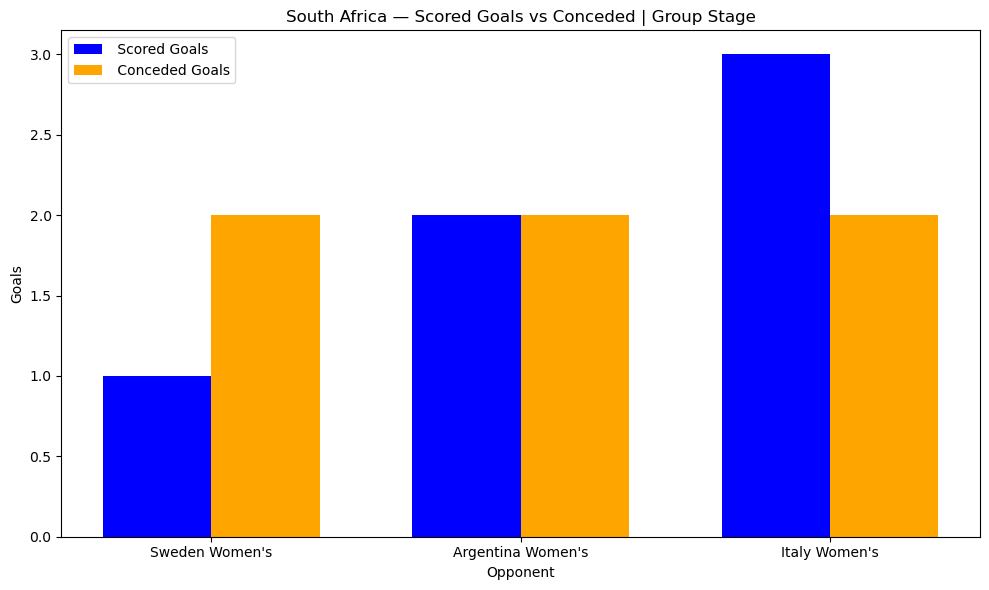

In [77]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "South Africa Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("South Africa — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

South Africa won one game, lost one, and tied another. In total, they scored 6 goals and conceded 6 goals. This may reflect strong offensive production—scoring in every game—but also a defensive lapse—conceding goals in every game.

In [104]:
group_games[
    ["match_date", "opponent", "xG", "goals_for"]
]

,match_date,opponent,xG,goals_for
18,2023-07-23,Sweden Women's,1.036705,1
51,2023-07-28,Argentina Women's,2.176067,2
89,2023-08-02,Italy Women's,0.772271,3


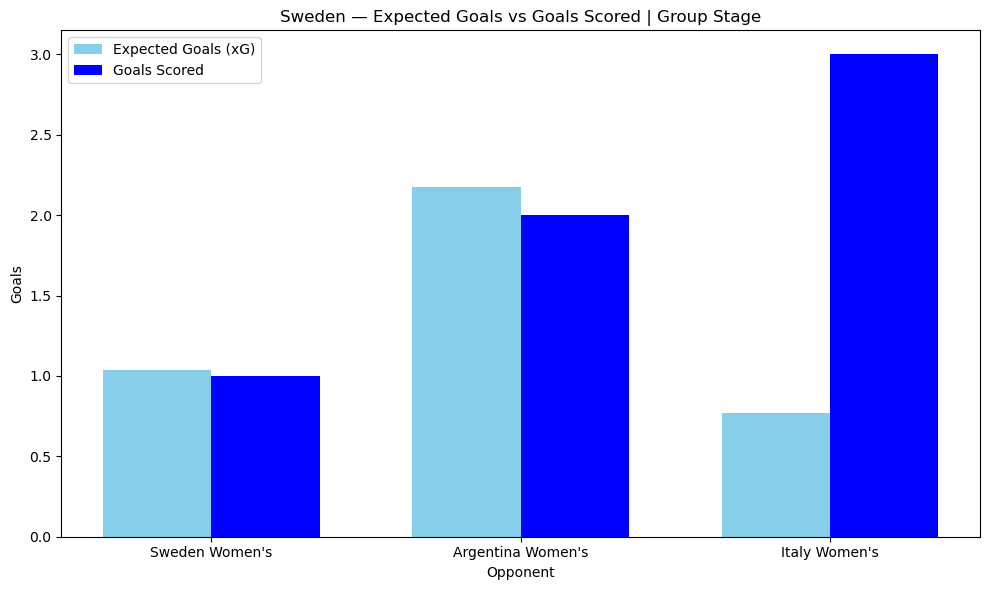

In [116]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "South Africa Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Sweden — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Unlike Sweden, the South African national team underperformed relative to xG in one game, and in the game it won, it significantly exceeded expectations. 

# Analysis SWE-ITA

In [87]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "South Africa": [
        match.loc[
            match["team"] == "South Africa Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Italy": [
        match.loc[
            match["team"] == "Italy Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["South Africa", "Italy"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["South Africa", "Italy"]
].round(1)


# Display table

comparison

,Metric,South Africa,Italy
0,Goals,3.0,2.0
1,xG,0.8,3.2
2,Goals Minus xG,1.2,-1.2
3,Shots,12.0,17.0
4,Shots on Target,5.0,7.0
5,Saves,5.0,3.0
6,Possession %,36.3,63.7
7,Pass Accuracy %,57.9,76.6
8,Progressive Passes,91.0,132.0
9,Progressive Carries,8.0,23.0


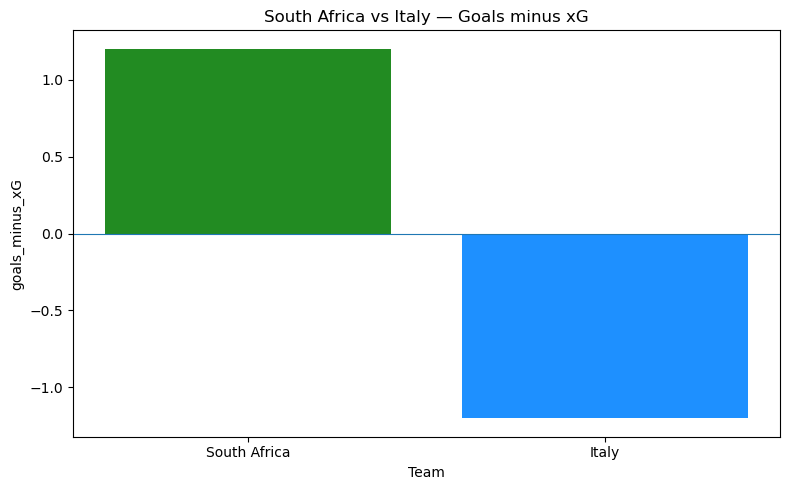

In [89]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    )
].copy()


teams = ["South Africa", "Italy"]

goals_minus_xG = [
    match.loc[match["team"] == "South Africa Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Italy Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["forestgreen", "dodgerblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("South Africa vs Italy — Goals minus xG")

plt.tight_layout()
plt.show()

In this chart, South Africa outperformed its xG, scoring more than expected. This was not the case for Italy, which failed to exceed its xG.

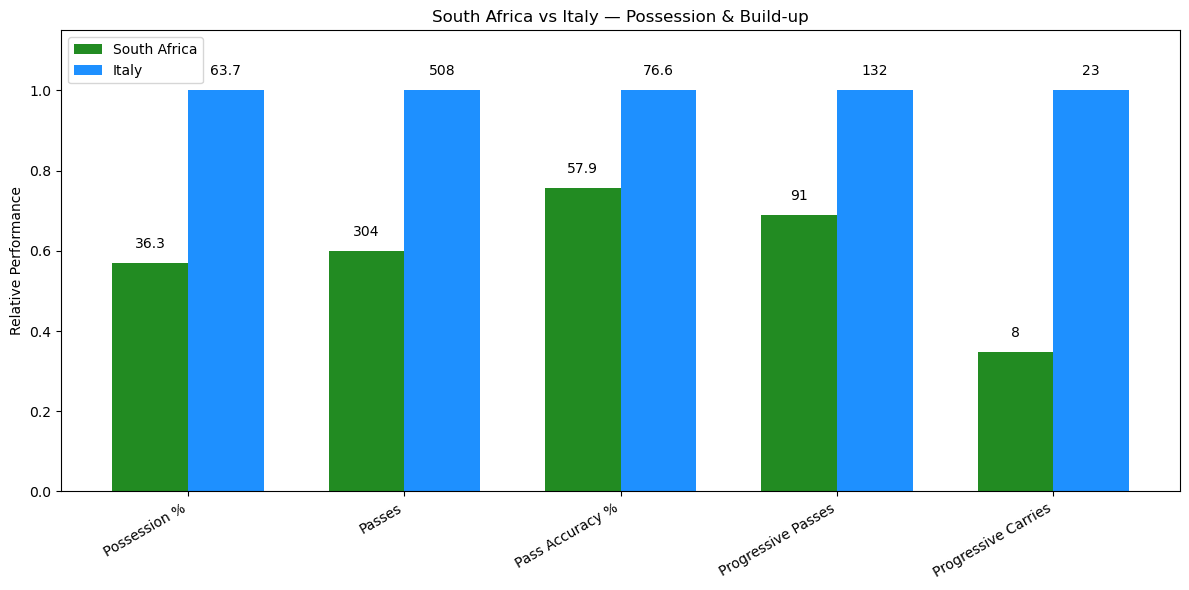

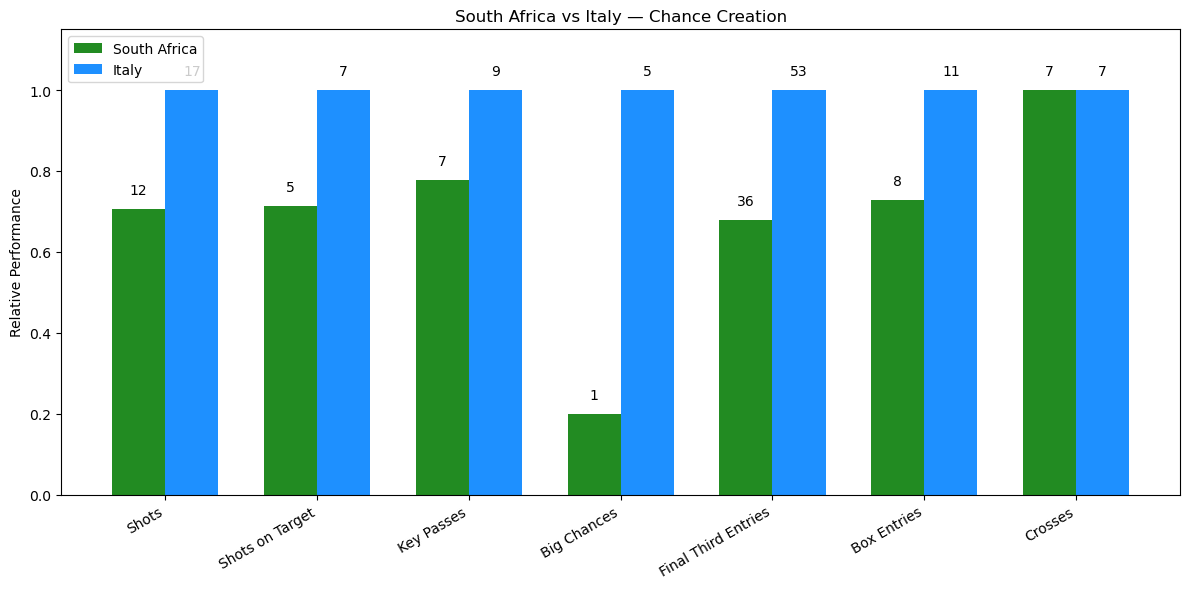

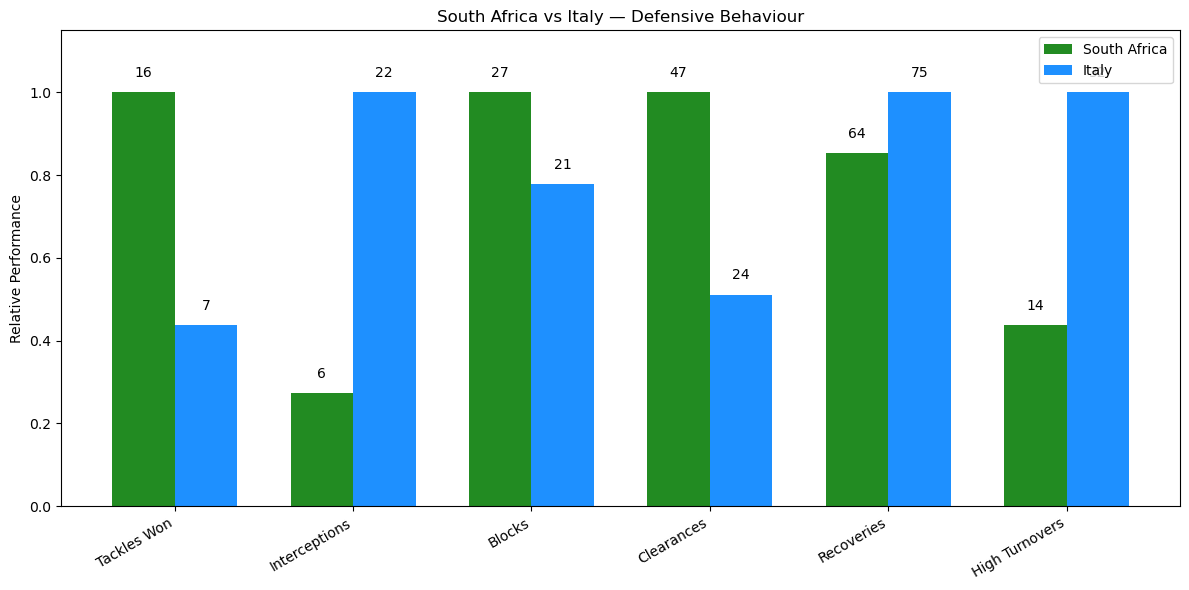

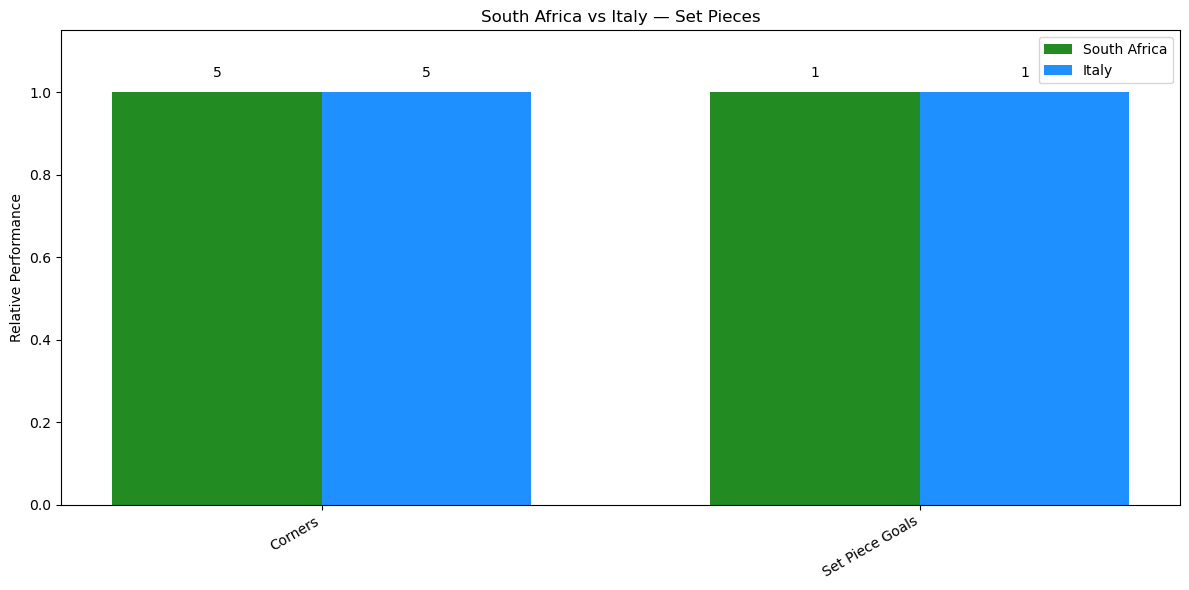

In [95]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "South Africa": "South Africa Women's",
    "Italy": "Italy Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    rsa_values = np.array([
        match.loc[
            match["team"] == team_names["South Africa"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    ita_values = np.array([
        match.loc[
            match["team"] == team_names["Italy"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(rsa_values, ita_values)

    # Normalize
    rsa_normalized = np.divide(
        rsa_values,
        max_values,
        out=np.zeros_like(rsa_values),
        where=max_values != 0
    )

    ita_normalized = np.divide(
        ita_values,
        max_values,
        out=np.zeros_like(ita_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_rsa = plt.bar(
        x - width / 2,
        rsa_normalized,
        width,
        label="South Africa",
        color="forestgreen"
    )

    bars_ita = plt.bar(
        x + width / 2,
        ita_normalized,
        width,
        label="Italy",
        color="dodgerblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_rsa, rsa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_ita, ita_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"South Africa vs Italy — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion RSA-ITA

Italy performed better overall, particularly in possession and build-up, where they showed greater control and progression. However, South Africa were more effective in turning key moments into goals and won 3-2. Italy's two goals came from set pieces — a penalty and a corner — while one of South Africa's three goals was an own goal by Italy. This is important when evaluating efficiency, as the scoreline does not fully reflect each team's attacking performance. Italy appeared more complete, while South Africa were more effective at capitalising on decisive moments.

# Analysis RSA-ARG

In [100]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "South Africa": [
        match.loc[
            match["team"] == "South Africa Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Argentina": [
        match.loc[
            match["team"] == "Argentina Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["South Africa", "Argentina"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["South Africa", "Argentina"]
].round(1)


# Display table

comparison

,Metric,South Africa,Argentina
0,Goals,2.0,2.0
1,xG,2.2,0.6
2,Goals Minus xG,-0.2,1.4
3,Shots,13.0,13.0
4,Shots on Target,4.0,4.0
5,Saves,2.0,2.0
6,Possession %,40.1,59.9
7,Pass Accuracy %,63.8,75.6
8,Progressive Passes,97.0,121.0
9,Progressive Carries,19.0,16.0


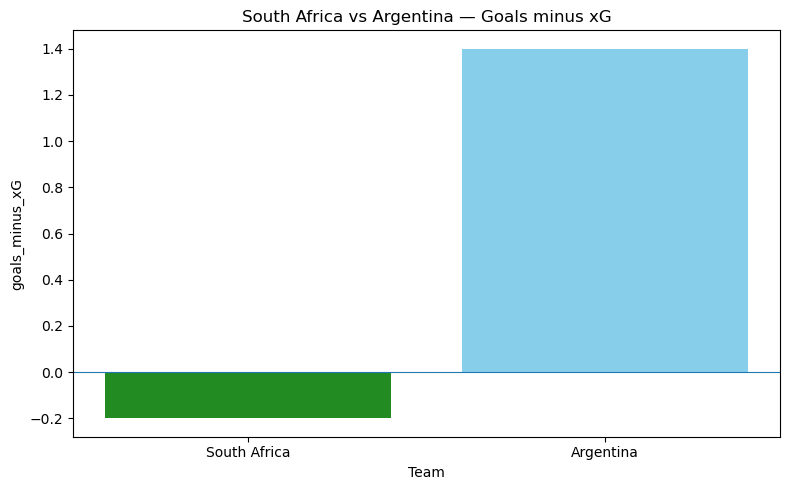

In [102]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    )
].copy()

teams = ["South Africa", "Argentina"]

goals_minus_xG = [
    match.loc[match["team"] == "South Africa Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Argentina Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["forestgreen", "skyblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("South Africa vs Argentina — Goals minus xG")

plt.tight_layout()
plt.show()

South Africa underperformed on the game with argentina, giving their xG. However, Argentina surprised by having a bigger score than xG.

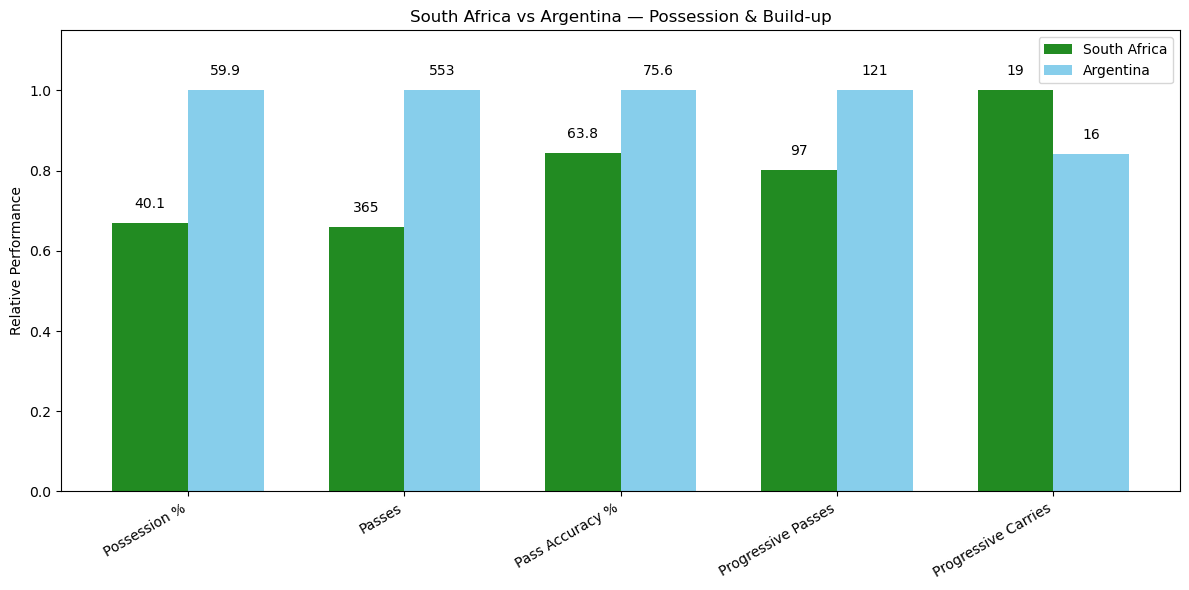

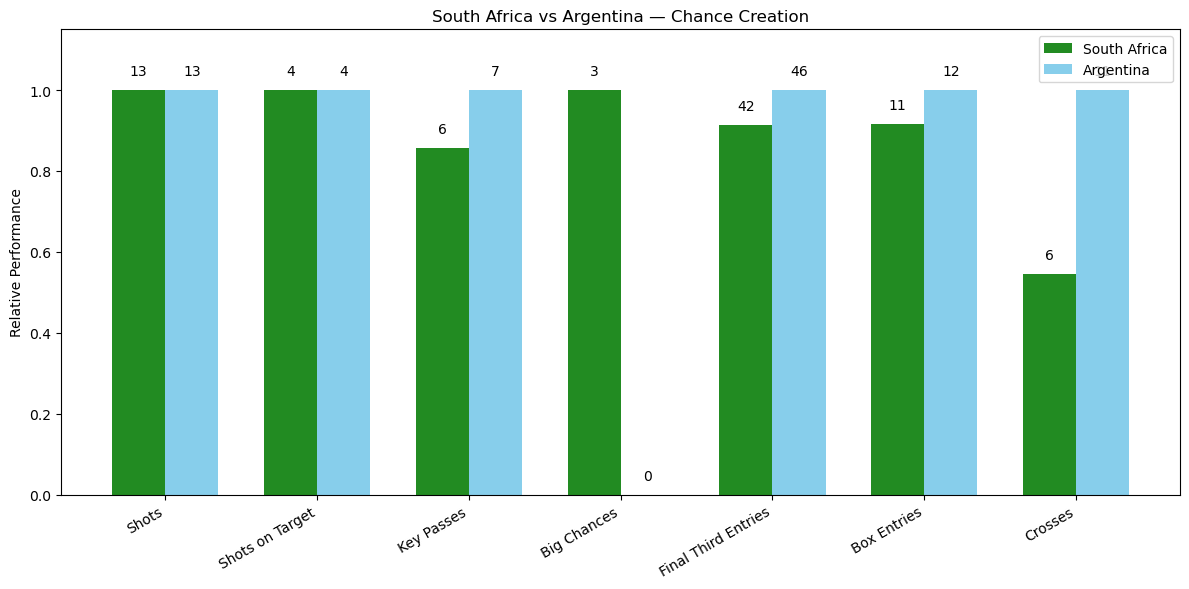

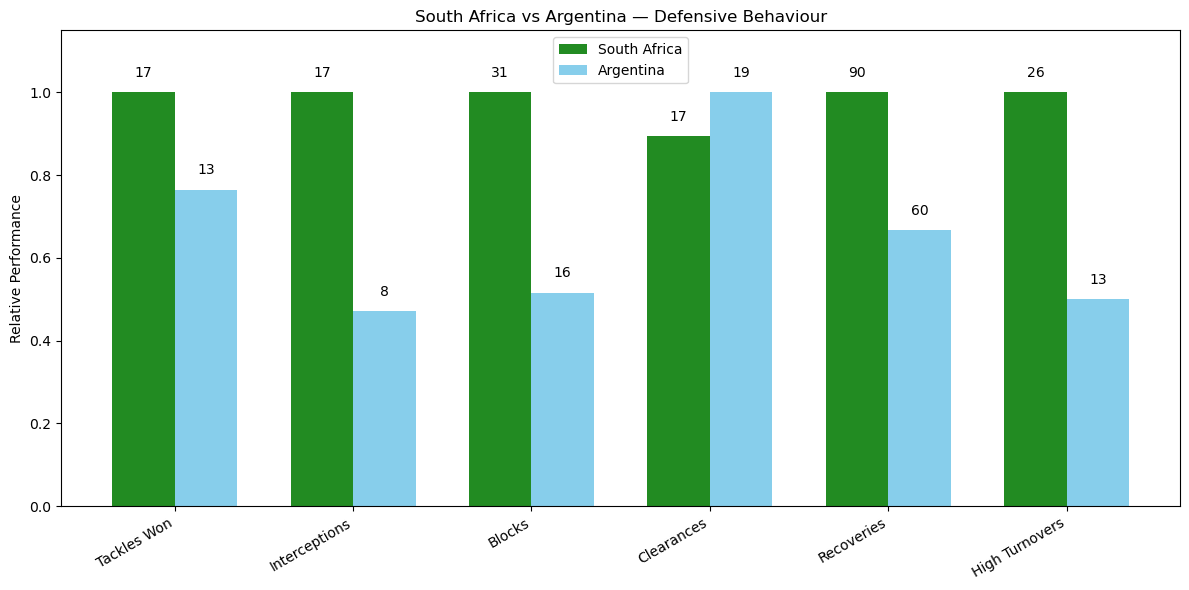

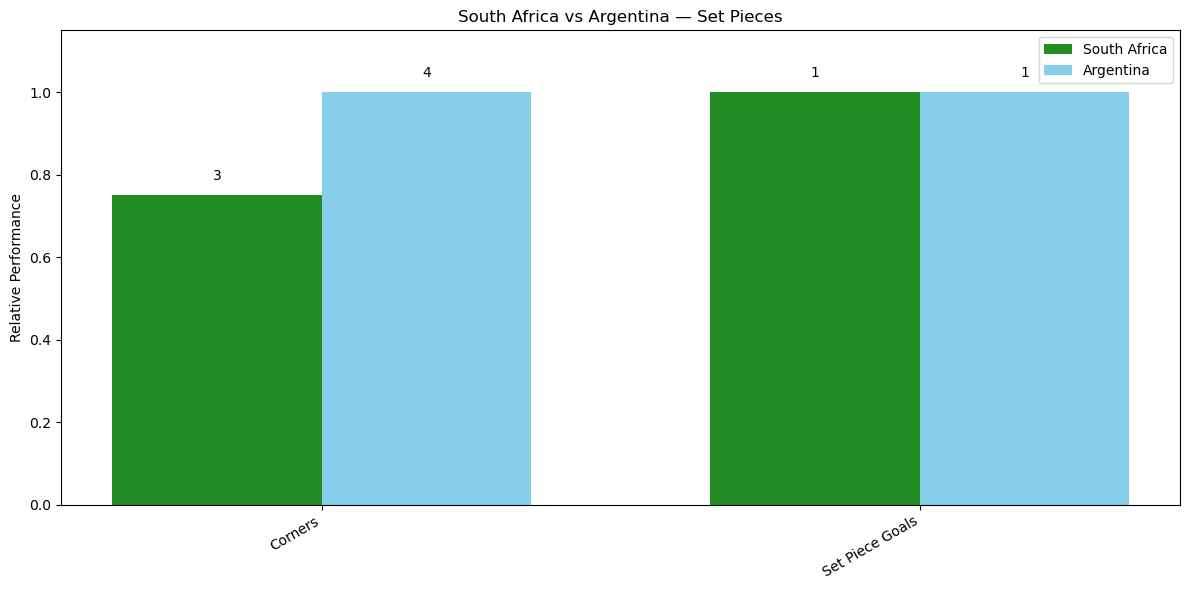

In [124]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "South Africa Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "South Africa Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "South Africa": "South Africa Women's",
    "Argentina": "Argentina Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    rsa_values = np.array([
        match.loc[
            match["team"] == team_names["South Africa"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    arg_values = np.array([
        match.loc[
            match["team"] == team_names["Argentina"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(rsa_values, arg_values)

    # Normalize
    rsa_normalized = np.divide(
        rsa_values,
        max_values,
        out=np.zeros_like(rsa_values),
        where=max_values != 0
    )

    arg_normalized = np.divide(
        arg_values,
        max_values,
        out=np.zeros_like(arg_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_rsa = plt.bar(
        x - width / 2,
        rsa_normalized,
        width,
        label="South Africa",
        color="forestgreen"
    )

    bars_arg = plt.bar(
        x + width / 2,
        arg_normalized,
        width,
        label="Argentina",
        color="skyblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_rsa, rsa_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_arg, arg_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"South Africa vs Argentina — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion RSA-ARG

Argentina showed stronger involvement in possession and build-up, with an advantage in passing and progression, while South Africa were competitive across the attacking and defensive phases. The result suggests that South Africa were better at turning their opportunities and defensive actions into a decisive advantage, despite Argentina showing greater control in parts of the game.

# Analysis Italy's Group Stage games

In [129]:
team = "Italy Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
26,3893800,Argentina Women's,Italy Women's,Group
27,3893800,Italy Women's,Argentina Women's,Group
54,3893814,Italy Women's,Sweden Women's,Group
55,3893814,Sweden Women's,Italy Women's,Group
88,3893831,Italy Women's,South Africa Women's,Group
89,3893831,South Africa Women's,Italy Women's,Group


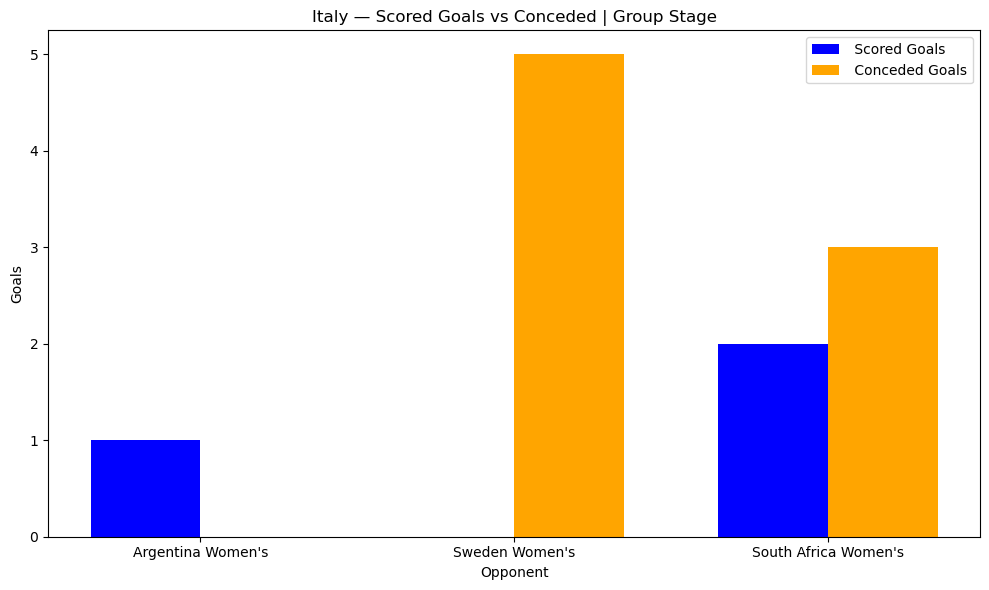

In [131]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Italy Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Italy — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Italy lost two games and won one. The chart shows that, in total, they scored 3 goals and conceded 8, which points to difficulties in their defensive performance

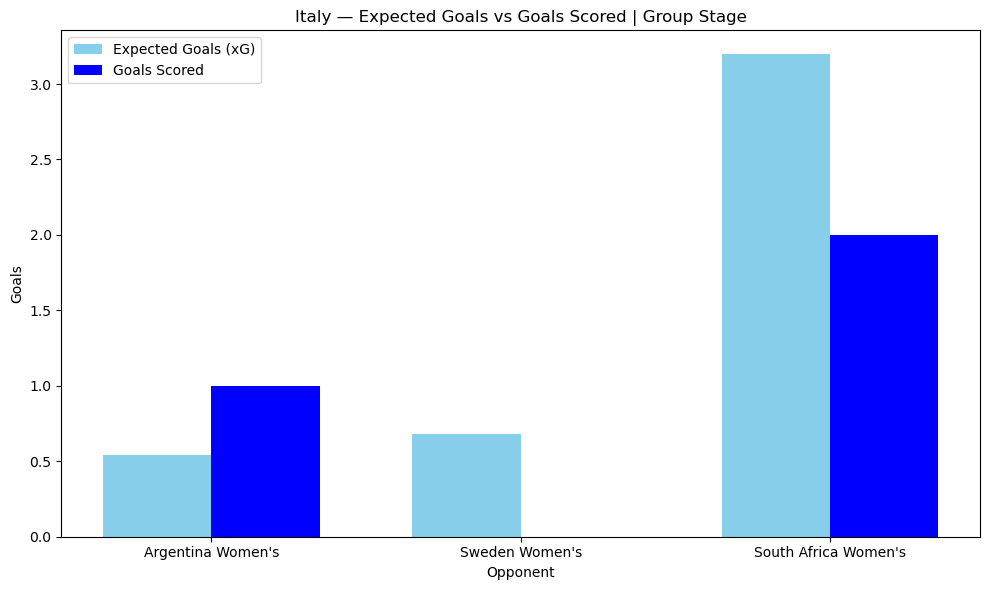

In [133]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Italy Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Italy — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Italy exceeded expectations in just one game; in the other two, it did not exceed xG.

# Analysis ITA-ARG

In [137]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    )
].copy()


# Metrics to compare

metrics = {
    "Goals": "goals_for",
    "xG": "xG",
    "Goals Minus xG": "goals_minus_xG",
    "Shots": "shots",
    "Shots on Target": "shots_on_target",
    "Saves": "saves",
    "Possession %": "possession_pct",
    "Pass Accuracy %": "pass_accuracy_pct",
    "Progressive Passes": "progressive_passes",
    "Progressive Carries": "progressive_carries",
    "Final Third Entries": "final_third_entries",
    "Box Entries": "box_entries",
    "High Turnovers": "high_turnovers",
    "Tackles Won": "tackles_won",
    "Interceptions": "interceptions",
    "Blocks": "blocks",
    "Clearances": "clearances",
    "Recoveries": "recoveries"
}


# Create comparison table

comparison = pd.DataFrame({
    "Metric": metrics.keys(),

    "Italy": [
        match.loc[
            match["team"] == "Italy Women's", column
        ].iloc[0]
        for column in metrics.values()
    ],

    "Argentina": [
        match.loc[
            match["team"] == "Argentina Women's", column
        ].iloc[0]
        for column in metrics.values()
    ]
})


# Round selected metrics to 1 decimal place

decimal_metrics = [
    "xG",
    "Goals Minus xG",
    "Possession %",
    "Pass Accuracy %"
]

comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Italy", "Argentina"]
] = comparison.loc[
    comparison["Metric"].isin(decimal_metrics),
    ["Italy", "Argentina"]
].round(1)


# Display table

comparison

,Metric,Italy,Argentina
0,Goals,1.0,0.0
1,xG,0.5,0.2
2,Goals Minus xG,0.5,-0.2
3,Shots,12.0,5.0
4,Shots on Target,4.0,1.0
5,Saves,1.0,3.0
6,Possession %,56.0,44.0
7,Pass Accuracy %,75.6,72.4
8,Progressive Passes,113.0,74.0
9,Progressive Carries,19.0,11.0


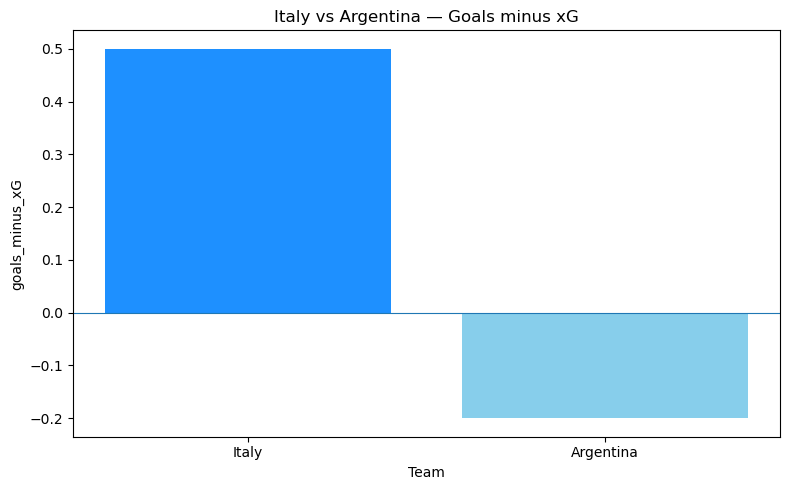

In [141]:
match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    )
].copy()

teams = ["Italy", "Argentina"]

goals_minus_xG = [
    match.loc[match["team"] == "Italy Women's", "goals_minus_xG"].iloc[0],
    match.loc[match["team"] == "Argentina Women's", "goals_minus_xG"].iloc[0]
]

goals_minus_xG = np.round(goals_minus_xG, 1)

plt.figure(figsize=(8, 5))

plt.bar(
    teams,
    goals_minus_xG,
    color=["dodgerblue", "skyblue"]
)

plt.axhline(0, linewidth=0.8)

plt.xlabel("Team")
plt.ylabel("goals_minus_xG")
plt.title("Italy vs Argentina — Goals minus xG")

plt.tight_layout()
plt.show()

Italy performed better by scoring more goals than its xG. Argentina, on the other hand, failed to score any goals and did not achieve a better result.

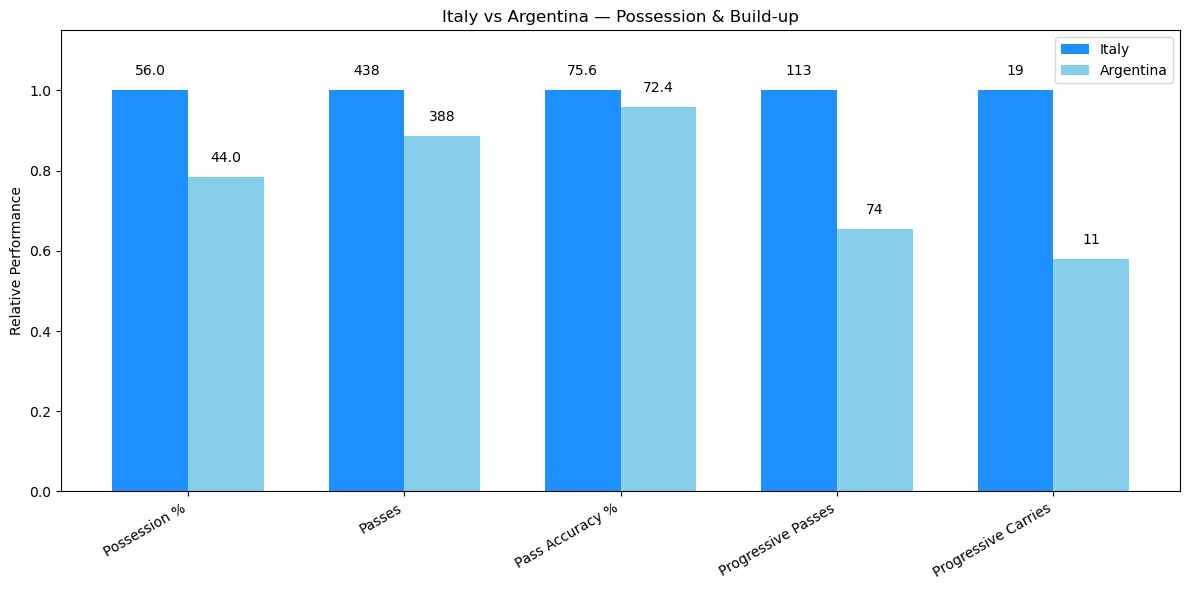

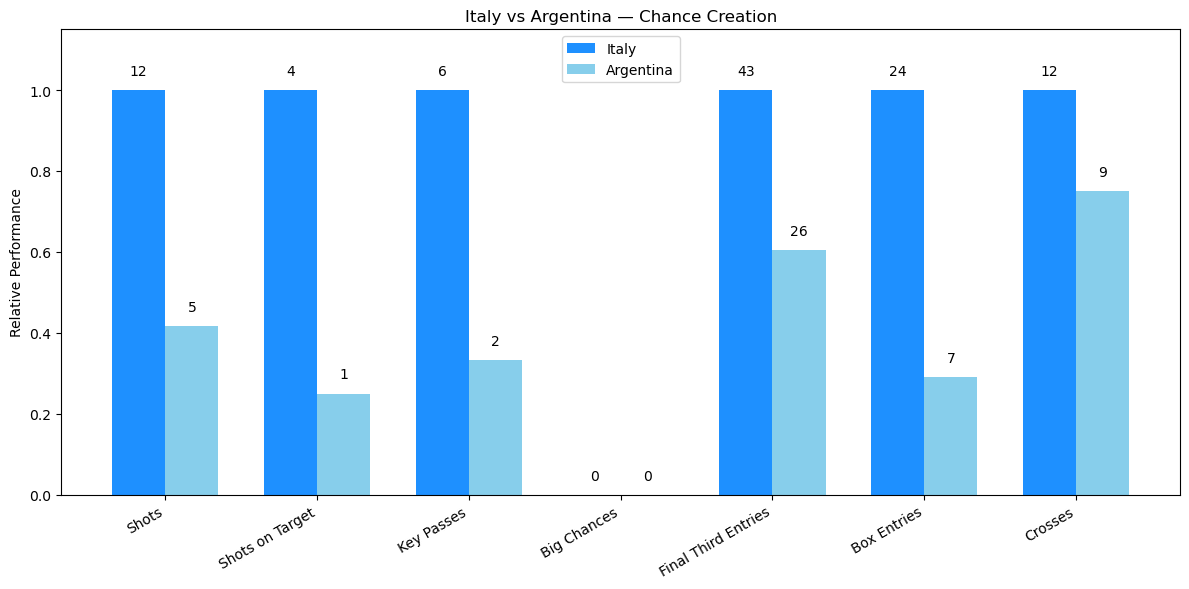

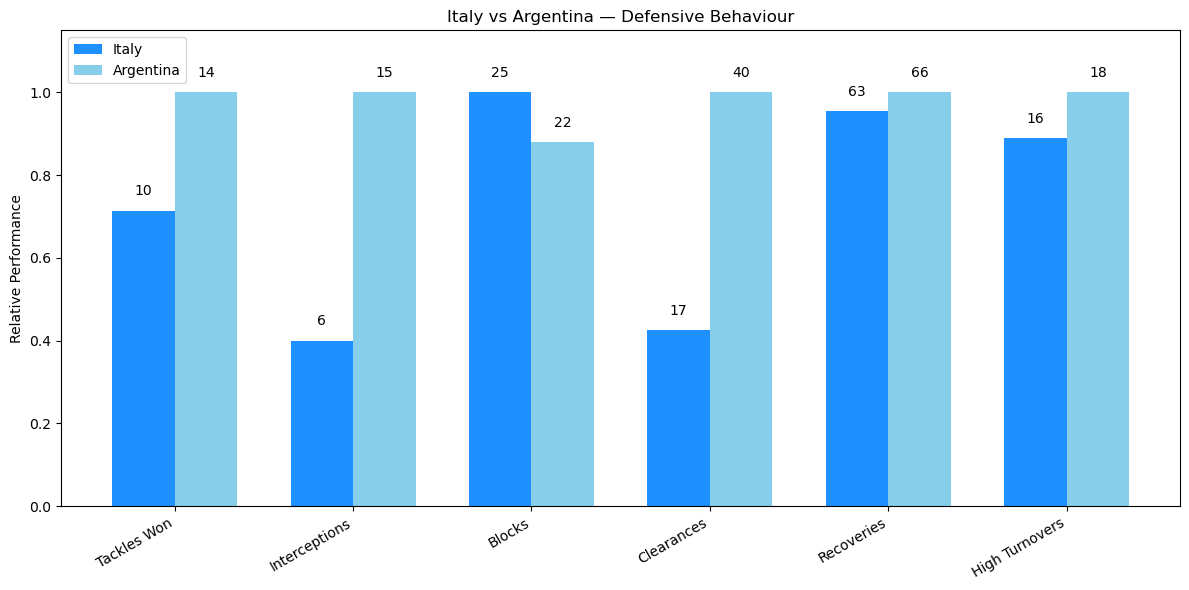

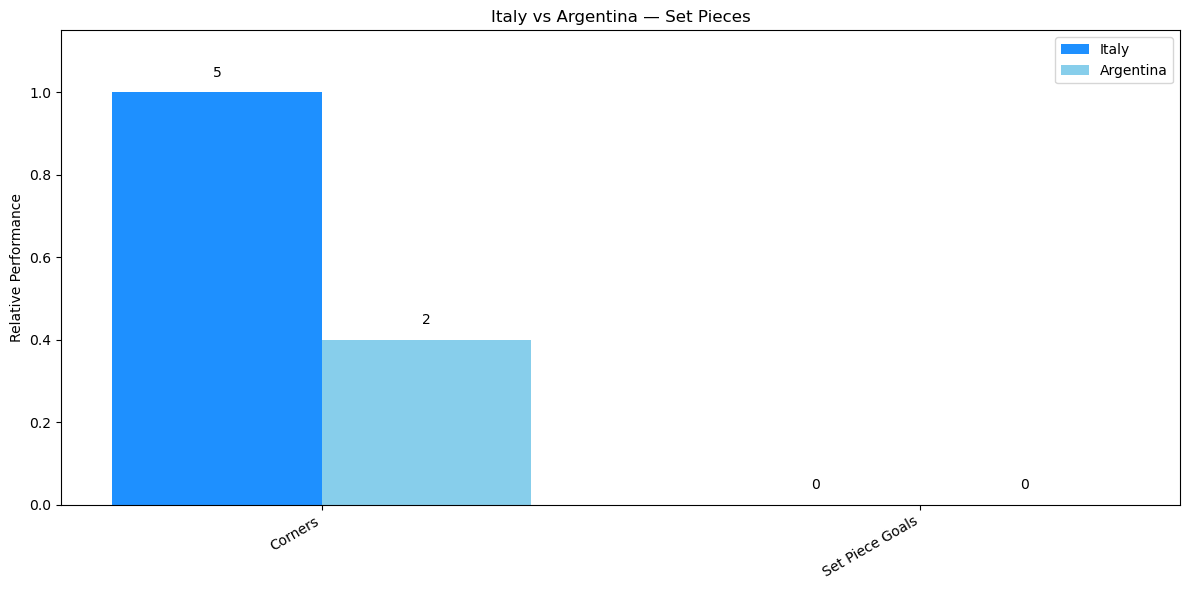

In [144]:
import matplotlib.pyplot as plt
import numpy as np

match = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == "Italy Women's") &
        (womens_world_cup_stats["opponent"] == "Argentina Women's")
    ) |
    (
        (womens_world_cup_stats["team"] == "Argentina Women's") &
        (womens_world_cup_stats["opponent"] == "Italy Women's")
    )
].copy()


# ============================================================
# 1. DEFINE THE CATEGORIES
# ============================================================

categories = {
    "Possession & Build-up": {
        "Possession %": "possession_pct",
        "Passes": "passes",
        "Pass Accuracy %": "pass_accuracy_pct",
        "Progressive Passes": "progressive_passes",
        "Progressive Carries": "progressive_carries"
    },

    "Chance Creation": {
        "Shots": "shots",
        "Shots on Target": "shots_on_target",
        "Key Passes": "key_passes",
        "Big Chances": "big_chances",
        "Final Third Entries": "final_third_entries",
        "Box Entries": "box_entries",
        "Crosses": "crosses"
    },

    "Defensive Behaviour": {
        "Tackles Won": "tackles_won",
        "Interceptions": "interceptions",
        "Blocks": "blocks",
        "Clearances": "clearances",
        "Recoveries": "recoveries",
        "High Turnovers": "high_turnovers"
    },

    "Set Pieces": {
        "Corners": "corners",
        "Set Piece Goals": "set_piece_goals"
    }
}


# ============================================================
# 2. TEAMS
# ============================================================

team_names = {
    "Italy": "Italy Women's",
    "Argentina": "Argentina Women's"
}


# ============================================================
# 3. CREATE EACH CHART
# ============================================================

for category_name, metrics in categories.items():

    # Get real values
    ita_values = np.array([
        match.loc[
            match["team"] == team_names["Italy"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    arg_values = np.array([
        match.loc[
            match["team"] == team_names["Argentina"],
            column
        ].iloc[0]
        for column in metrics.values()
    ], dtype=float)

    # Maximum value for each metric
    max_values = np.maximum(ita_values, arg_values)

    # Normalize
    ita_normalized = np.divide(
        ita_values,
        max_values,
        out=np.zeros_like(ita_values),
        where=max_values != 0
    )

    arg_normalized = np.divide(
        arg_values,
        max_values,
        out=np.zeros_like(arg_values),
        where=max_values != 0
    )

    # Position of bars
    x = np.arange(len(metrics))
    width = 0.35

    # Create figure
    plt.figure(figsize=(12, 6))

    bars_ita = plt.bar(
        x - width / 2,
        ita_normalized,
        width,
        label="Italy",
        color="dodgerblue"
    )

    bars_arg = plt.bar(
        x + width / 2,
        arg_normalized,
        width,
        label="Argentina",
        color="skyblue"
    )

    # ========================================================
    # REAL VALUES ABOVE BARS
    # ========================================================

    for bar, value in zip(bars_ita, ita_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    for bar, value in zip(bars_arg, arg_values):

        if value.is_integer():
            label = f"{int(value)}"
        else:
            label = f"{value:.1f}"

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.03,
            label,
            ha="center",
            va="bottom"
        )

    # ========================================================
    # LABELS
    # ========================================================

    plt.xticks(
        x,
        metrics.keys(),
        rotation=30,
        ha="right"
    )

    plt.ylabel("Relative Performance")

    plt.title(
        f"Italy vs Argentina — {category_name}"
    )

    plt.ylim(0, 1.15)

    plt.legend()

    plt.tight_layout()

    plt.show()

## Conclusion ITA-ARG

Italy maintained an attacking stance throughout the game, posting higher numbers than Argentina in most metrics. However, in terms of possession, the numbers were even, reflecting a balanced game.
Argentina showed its defensive tenacity, posting higher numbers than its rival.

# Analysis Argentina's Group Stage games

In [149]:
team = "Argentina Women's"

games = womens_world_cup_stats[
    (
        (womens_world_cup_stats["team"] == team) |
        (womens_world_cup_stats["opponent"] == team)
    )
    &
    (womens_world_cup_stats["stage"] == "Group")
]

games[["match_id", "team", "opponent", "stage"]]

,match_id,team,opponent,stage
26,3893800,Argentina Women's,Italy Women's,Group
27,3893800,Italy Women's,Argentina Women's,Group
50,3893812,Argentina Women's,South Africa Women's,Group
51,3893812,South Africa Women's,Argentina Women's,Group
86,3893830,Argentina Women's,Sweden Women's,Group
87,3893830,Sweden Women's,Argentina Women's,Group


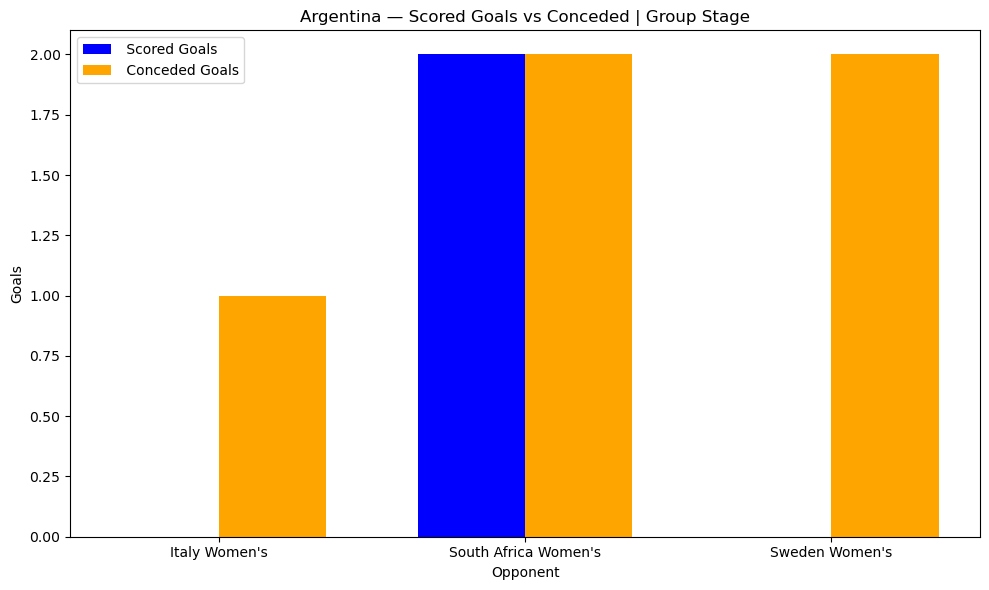

In [151]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Argentina Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["goals_for"],
    width,
    label=" Scored Goals",
    color = "blue"
)

plt.bar(
    x + width / 2,
    group_games["goals_against"],
    width,
    label= " Conceded Goals",
    color = "orange"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Argentina — Scored Goals vs Conceded | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Argentina lost two games and tied one (against South Africa). The South American team scored 2 goals but conceded 5. 

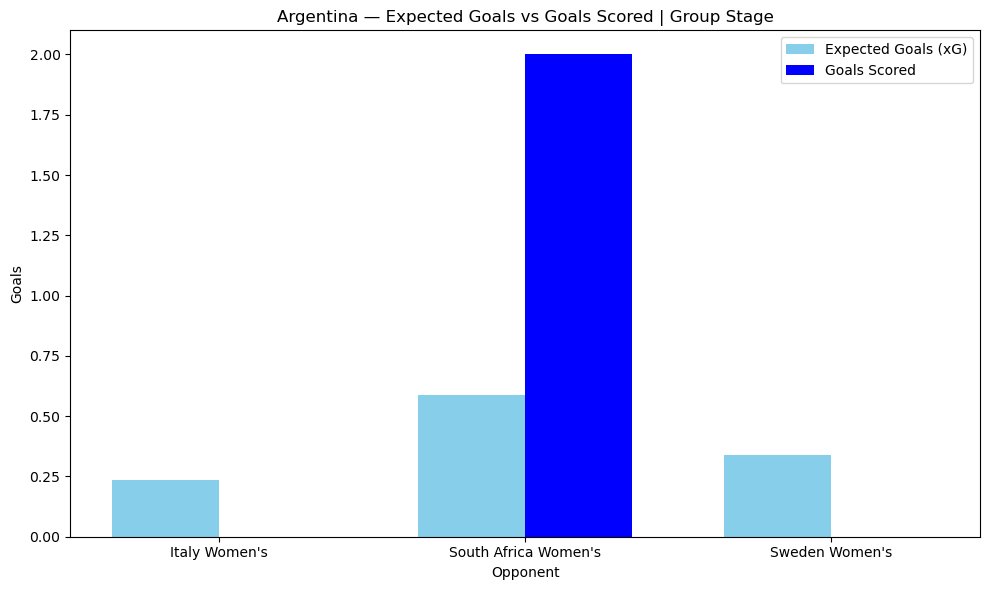

In [155]:
group_games = womens_world_cup_stats[
    (womens_world_cup_stats["team"] == "Argentina Women's") &
    (womens_world_cup_stats["stage"] == "Group")
].copy()

group_games["match_date"] = pd.to_datetime(group_games["match_date"])

group_games = group_games.sort_values("match_date")

x = np.arange(len(group_games))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    group_games["xG"],
    width,
    label="Expected Goals (xG)",
    color="skyblue"
)

plt.bar(
    x + width / 2,
    group_games["goals_for"],
    width,
    label="Goals Scored",
    color="blue"
)

plt.xticks(
    x,
    group_games["opponent"]
)

plt.xlabel("Opponent")
plt.ylabel("Goals")
plt.title("Argentina — Expected Goals vs Goals Scored | Group Stage")

plt.legend()

plt.tight_layout()
plt.show()

Argentina's goals scored were below its xG, except in the match against South Africa, in which it scored 2 goals, while its xG was 0.5. 

# Final conclusion Group G

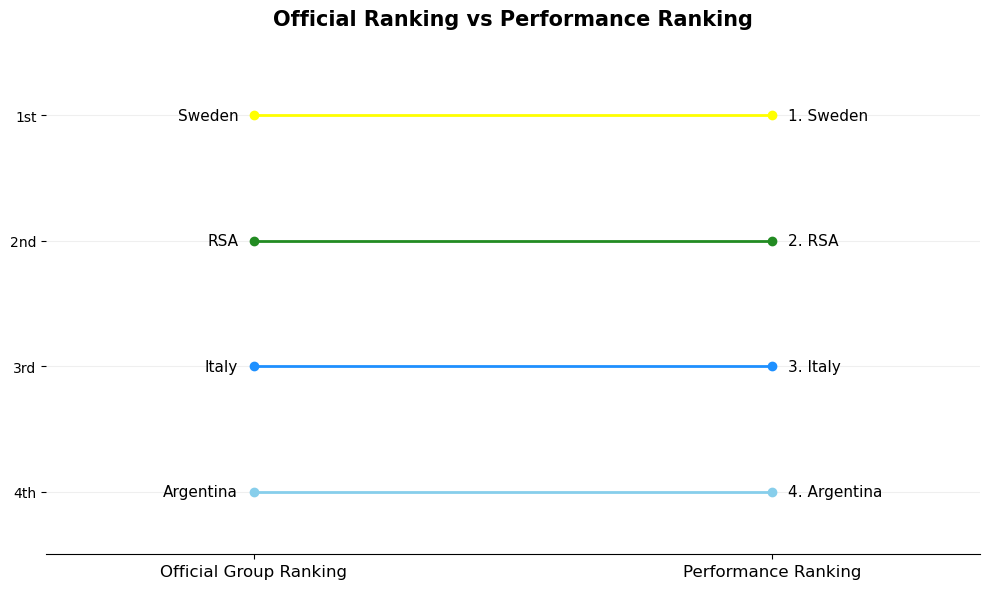

In [159]:
import matplotlib.pyplot as plt
import pandas as pd

# ==========================================
# DATA
# ==========================================

ranking = pd.DataFrame({
    "team": ["Sweden", "RSA", "Italy", "Argentina"],
    "official_rank": [1, 2, 3, 4],
    "performance_rank": [1, 2, 3, 4]
})

# ==========================================
# COLORS
# ==========================================

team_colors = {
    "Sweden": "yellow",
    "RSA": "forestgreen",
    "Italy": "dodgerblue",
    "Argentina": "skyblue"
}

# ==========================================
# PLOT
# ==========================================

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in ranking.iterrows():

    ax.plot(
        [0, 1],
        [row["official_rank"], row["performance_rank"]],
        marker="o",
        linewidth=2,
        color=team_colors[row["team"]]
    )

    # Official ranking
    ax.text(
        -0.03,
        row["official_rank"],
        row["team"],
        ha="right",
        va="center",
        fontsize=11
    )

    # Performance ranking
    ax.text(
        1.03,
        row["performance_rank"],
        f'{row["performance_rank"]}. {row["team"]}',
        ha="left",
        va="center",
        fontsize=11
    )

# ==========================================
# FORMATTING
# ==========================================

ax.set_xlim(-0.4, 1.4)
ax.set_ylim(4.5, 0.5)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    "Official Group Ranking",
    "Performance Ranking"
], fontsize=12)

ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(["1st", "2nd", "3rd", "4th"])

ax.set_title(
    "Official Ranking vs Performance Ranking",
    fontsize=15,
    fontweight="bold",
    pad=20
)

ax.grid(axis="y", alpha=0.2)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

I kept the same rankings as in the competition, highlighting Sweden as the team that stood out the most in this group. 
Based on xG—as reflected in the performance recorded in the games analyzed—Sweden was the team that performed best relative to its opponents.
The other teams had lapses that I felt significantly impacted their performance, such as defensive issues, lack of possession, and difficulty finishing.